<a href="https://colab.research.google.com/github/kakullyaarrr/hdfc-bank-ai-fraud-detection/blob/main/HDFC_Fraud_Detection_SmartKart_Style_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 HDFC — Fraud Detection
## Complete SmartKart-Style ML Pipeline

**Course:** Introduction to AI & ML | BBA FinTech & AI  
**Business Goal:** Predict whether a banking transaction is fraudulent and produce a business-ready fraud-risk report.

### Pipeline followed
1. Data Collection  
2. Data Understanding / Inspection  
3. Data Cleaning  
4. Feature Selection  
5. Define Target Variable  
6. Target Encoding  
7. Train-Test Split  
8. Preprocessing Pipeline  
9. Logistic Regression  
10. Random Forest  
11. XGBoost  
12. Isolation Forest  
13. Model Evaluation  
14. Model Comparison & Interpretation  
15. Final Fraud-Risk Output

> **Important:** The earlier HDFC notebook mainly contained hard-coded Precision-Recall values and curves. This version actually trains the models from the uploaded transaction dataset, so the reported metrics are generated from the data rather than typed manually.


---
## Step 1 — Data Collection

**What:** Upload the HDFC transaction CSV into Google Colab.  
**Why:** The ML pipeline must start from the actual transaction data.

The code accepts common fraud-target names such as `is_fraud`, `fraud`, `fraud_flag`, `Fraud`, or `Class`. If your target has a different name, you can set it manually in the configuration cell.


In [6]:
# ============================================================
# STEP 1: DATA COLLECTION
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Upload the HDFC transaction dataset
uploaded = files.upload()

# Read the first uploaded CSV file automatically
csv_files = [name for name in uploaded.keys() if name.lower().endswith(".csv")]

if not csv_files:
    raise FileNotFoundError("Please upload a CSV transaction dataset.")

DATA_FILE = csv_files[0]
df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully:", DATA_FILE)
print("Shape:", df.shape)

display(df.head())


Saving hdfc_transactions.csv to hdfc_transactions (1).csv
Dataset loaded successfully: hdfc_transactions (1).csv
Shape: (6000, 15)


,transaction_id,customer_id,transaction_date,transaction_time,amount,merchant_category,transaction_type,device_type,card_present,home_city,transaction_city,distance_from_home_km,account_age_days,prev_txn_count_24h,is_fraud
0,501783,102368,2026-04-15,11:43:00,1812.26,ATM Withdrawal,POS,Web Browser,No,Rajpura,Rajpura,12.5,3906,1,0
1,503918,184978,2026-01-05,01:27:00,66182.30,Dining,ONLINE,USSD,No,Chennai,Bengaluru,1389.9,24,4,1
2,500222,145577,2026-05-07,02:48:00,5041.90,E-commerce,ONLINE,USSD,No,Chennai,Chennai,5.1,2486,1,0
3,502136,168542,2026-08-28,22:27:00,12029.35,Travel,ONLINE,Mobile App,Yes,Hyderabad,Hyderabad,4.6,3445,1,0
4,505225,152800,2026-03-25,16:47:00,245.84,ATM Withdrawal,POS,Mobile App,Yes,Ahmedabad,Ahmedabad,8.8,3046,2,0


---
## Step 2 — Data Understanding / Inspection

**What:** Inspect rows, columns, data types, missing values, duplicates, and the target distribution.  
**Why:** Fraud datasets are often highly imbalanced, and transaction IDs should not automatically be treated as predictive features.


In [7]:
# ============================================================
# STEP 2: DATA UNDERSTANDING / INSPECTION
# ============================================================

print("Shape (rows, columns):", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("Missing_Count"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nStatistical summary:")
display(df.describe(include="all").T)

print("\nFirst 5 rows:")
display(df.head())


Shape (rows, columns): (6000, 15)

Column names:
['transaction_id', 'customer_id', 'transaction_date', 'transaction_time', 'amount', 'merchant_category', 'transaction_type', 'device_type', 'card_present', 'home_city', 'transaction_city', 'distance_from_home_km', 'account_age_days', 'prev_txn_count_24h', 'is_fraud']

Data types:
transaction_id             int64
customer_id                int64
transaction_date          object
transaction_time          object
amount                   float64
merchant_category         object
transaction_type          object
device_type               object
card_present              object
home_city                 object
transaction_city          object
distance_from_home_km    float64
account_age_days           int64
prev_txn_count_24h         int64
is_fraud                   int64
dtype: object

Missing values:


,Missing_Count
transaction_id,0
customer_id,0
transaction_date,0
transaction_time,0
amount,0
merchant_category,0
transaction_type,0
device_type,0
card_present,0
home_city,0



Duplicate rows: 0

Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,6000.0,NaN,NaN,NaN,503000.5,1732.195139,500001.0,501500.75,503000.5,504500.25,506000.0
customer_id,6000.0,NaN,NaN,NaN,149890.4375,28842.527551,100000.0,124807.5,149677.0,175109.75,199975.0
transaction_date,6000,240,2026-08-11,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_time,6000,1414,09:45:00,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,6000.0,NaN,NaN,NaN,5585.992218,11167.320854,75.47,1816.7575,3175.735,5216.625,94731.45
merchant_category,6000,10,Fuel,627,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_type,6000,5,POS,1769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,6000,5,Web Browser,1258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
card_present,6000,2,Yes,3158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_city,6000,10,Hyderabad,633,NaN,NaN,NaN,NaN,NaN,NaN,NaN



First 5 rows:


,transaction_id,customer_id,transaction_date,transaction_time,amount,merchant_category,transaction_type,device_type,card_present,home_city,transaction_city,distance_from_home_km,account_age_days,prev_txn_count_24h,is_fraud
0,501783,102368,2026-04-15,11:43:00,1812.26,ATM Withdrawal,POS,Web Browser,No,Rajpura,Rajpura,12.5,3906,1,0
1,503918,184978,2026-01-05,01:27:00,66182.30,Dining,ONLINE,USSD,No,Chennai,Bengaluru,1389.9,24,4,1
2,500222,145577,2026-05-07,02:48:00,5041.90,E-commerce,ONLINE,USSD,No,Chennai,Chennai,5.1,2486,1,0
3,502136,168542,2026-08-28,22:27:00,12029.35,Travel,ONLINE,Mobile App,Yes,Hyderabad,Hyderabad,4.6,3445,1,0
4,505225,152800,2026-03-25,16:47:00,245.84,ATM Withdrawal,POS,Mobile App,Yes,Ahmedabad,Ahmedabad,8.8,3046,2,0


---
## Step 3 — Data Cleaning

**What:** Remove exact duplicate transactions, clean column names, convert obvious numeric-looking columns, and prepare the dataset for modeling.

**Why:** Cleaning should happen before model training, but transformations that learn statistics from the data are kept inside the preprocessing pipeline to reduce data leakage.


In [8]:
# ============================================================
# STEP 3: DATA CLEANING
# ============================================================

print("Rows before cleaning:", len(df))

# Standardise column names
df.columns = (
    df.columns.astype(str)
      .str.strip()
      .str.replace(r"[^A-Za-z0-9_]+", "_", regex=True)
      .str.strip("_")
)

# Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates().copy()
print("Duplicate rows removed:", before - len(df))

# Convert object columns that are mostly numeric into numeric values
for col in df.select_dtypes(include="object").columns:
    cleaned = df[col].astype(str).str.strip().str.replace(",", "", regex=False)
    numeric_version = pd.to_numeric(cleaned, errors="coerce")

    # Convert only when most non-empty values are numeric
    non_empty = cleaned.replace({"": np.nan, "nan": np.nan}).notna().sum()
    numeric_count = numeric_version.notna().sum()

    if non_empty > 0 and numeric_count / non_empty >= 0.90:
        df[col] = numeric_version

print("Rows after cleaning:", len(df))
print("\nRemaining missing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("Missing_Count"))

display(df.head())


Rows before cleaning: 6000
Duplicate rows removed: 0
Rows after cleaning: 6000

Remaining missing values:


,Missing_Count
transaction_id,0
customer_id,0
transaction_date,0
transaction_time,0
amount,0
merchant_category,0
transaction_type,0
device_type,0
card_present,0
home_city,0


,transaction_id,customer_id,transaction_date,transaction_time,amount,merchant_category,transaction_type,device_type,card_present,home_city,transaction_city,distance_from_home_km,account_age_days,prev_txn_count_24h,is_fraud
0,501783,102368,2026-04-15,11:43:00,1812.26,ATM Withdrawal,POS,Web Browser,No,Rajpura,Rajpura,12.5,3906,1,0
1,503918,184978,2026-01-05,01:27:00,66182.30,Dining,ONLINE,USSD,No,Chennai,Bengaluru,1389.9,24,4,1
2,500222,145577,2026-05-07,02:48:00,5041.90,E-commerce,ONLINE,USSD,No,Chennai,Chennai,5.1,2486,1,0
3,502136,168542,2026-08-28,22:27:00,12029.35,Travel,ONLINE,Mobile App,Yes,Hyderabad,Hyderabad,4.6,3445,1,0
4,505225,152800,2026-03-25,16:47:00,245.84,ATM Withdrawal,POS,Mobile App,Yes,Ahmedabad,Ahmedabad,8.8,3046,2,0


---
## Step 4 — Feature Selection

**What:** Separate the target from the model inputs and remove identifier-like columns.

**Why:** Transaction IDs, customer IDs, account numbers, reference numbers, and similar identifiers usually identify a record rather than explain fraud. Keeping them can create misleading patterns.


In [9]:
# ============================================================
# STEP 4: FEATURE SELECTION
# ============================================================

# Common fraud-target names
target_candidates = [
    "is_fraud", "fraud", "fraud_flag", "fraudulent",
    "Fraud", "Fraud_Flag", "Class", "class",
    "isFraud", "Is_Fraud", "Transaction_Fraud"
]

found_targets = [c for c in target_candidates if c in df.columns]

if found_targets:
    TARGET = found_targets[0]
else:
    # If automatic detection fails, change this manually.
    TARGET = "is_fraud"

if TARGET not in df.columns:
    print("Available columns:")
    print(df.columns.tolist())
    raise ValueError(
        f"Target column '{TARGET}' was not found. "
        "Set TARGET in this cell to your actual fraud-label column."
    )

print("Target column:", TARGET)

# Remove obvious identifier columns
id_keywords = [
    "id", "transaction_id", "transactionid", "customer_id",
    "customerid", "account_id", "accountid", "reference",
    "ref_no", "reference_no"
]

id_cols = []
for col in df.columns:
    if col == TARGET:
        continue
    name = col.lower()
    if name in id_keywords or name.endswith("_id") or name.endswith("id"):
        id_cols.append(col)

# Also remove columns with nearly unique values when they look like identifiers
for col in df.columns:
    if col == TARGET or col in id_cols:
        continue
    uniqueness = df[col].nunique(dropna=True) / max(len(df), 1)
    if uniqueness > 0.98 and ("date" not in col.lower()) and ("time" not in col.lower()):
        id_cols.append(col)

id_cols = sorted(set(id_cols))

X = df.drop(columns=[TARGET] + id_cols).copy()
y = df[TARGET].copy()

print("Identifier columns removed:", id_cols)
print("Features used:", X.columns.tolist())
print("Number of features:", X.shape[1])


Target column: is_fraud
Identifier columns removed: ['amount', 'customer_id', 'transaction_id']
Features used: ['transaction_date', 'transaction_time', 'merchant_category', 'transaction_type', 'device_type', 'card_present', 'home_city', 'transaction_city', 'distance_from_home_km', 'account_age_days', 'prev_txn_count_24h']
Number of features: 11


---
## Step 5 — Define Target Variable

**What:** Define `y` as the fraud label.

**Why:** This is a binary classification problem: genuine transaction vs fraudulent transaction.


In [10]:
# ============================================================
# STEP 5: DEFINE TARGET VARIABLE
# ============================================================

print("Target:", TARGET)
print("\nOriginal target values:")
print(y.value_counts(dropna=False))

print("\nTarget data type:", y.dtype)


Target: is_fraud

Original target values:
is_fraud
0    5790
1     210
Name: count, dtype: int64

Target data type: int64


---
## Step 6 — Encode Target Variable

**What:** Convert common text labels such as `Yes/No`, `Fraud/Legitimate`, or `True/False` into 1/0.

**Why:** Scikit-learn classification models require a numeric target.


In [11]:
# ============================================================
# STEP 6: TARGET ENCODING
# ============================================================

from sklearn.preprocessing import LabelEncoder

# Drop rows where the target is missing
valid_target = y.notna()
X = X.loc[valid_target].copy()
y = y.loc[valid_target].copy()

# Normalise common text labels
if y.dtype == "object" or str(y.dtype).startswith("string") or str(y.dtype) == "category":
    y_clean = y.astype(str).str.strip().str.lower()

    fraud_words = {"fraud", "fraudulent", "yes", "true", "1", "positive"}
    genuine_words = {"legitimate", "genuine", "no", "false", "0", "negative", "normal"}

    unique_values = set(y_clean.dropna().unique())

    if unique_values.issubset(fraud_words | genuine_words):
        y = y_clean.map(lambda v: 1 if v in fraud_words else 0).astype(int)
    else:
        le = LabelEncoder()
        y = pd.Series(le.fit_transform(y_clean), index=y.index, name=TARGET)

        if y.nunique() != 2:
            raise ValueError("The fraud target must contain exactly two classes.")

        print("LabelEncoder mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
else:
    # Convert numeric/bool targets to integers
    y = pd.to_numeric(y, errors="coerce")
    valid = y.notna()
    X = X.loc[valid].copy()
    y = y.loc[valid].astype(int)

# Force binary target
if y.nunique() != 2:
    raise ValueError(f"Expected 2 target classes, found {y.nunique()}: {y.unique()}")

# If labels are not 0/1, map the smaller/larger binary values to 0/1
if set(y.unique()) != {0, 1}:
    vals = sorted(y.unique())
    mapping = {vals[0]: 0, vals[1]: 1}
    y = y.map(mapping).astype(int)
    print("Numeric target mapping:", mapping)

print("Final target values:", sorted(y.unique()))
print("\nClass distribution:")
display(y.value_counts().rename(index={0:"Genuine (0)", 1:"Fraud (1)"}).to_frame("Transactions"))

print("\nClass distribution (%):")
display((y.value_counts(normalize=True) * 100).round(2).rename(index={0:"Genuine (0)", 1:"Fraud (1)"}).to_frame("Percentage"))


Final target values: [np.int64(0), np.int64(1)]

Class distribution:


,Transactions
is_fraud,
Genuine (0),5790
Fraud (1),210



Class distribution (%):


,Percentage
is_fraud,
Genuine (0),96.5
Fraud (1),3.5


---
## Step 7 — Train-Test Split

**What:** Reserve 20% of transactions for final testing.

**Why:** Fraud data is often imbalanced, so `stratify=y` keeps the fraud/genuine proportion approximately consistent between training and testing data.


In [12]:
# ============================================================
# STEP 7: TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
display(y_train.value_counts(normalize=True).rename(index={0:"Genuine", 1:"Fraud"}).mul(100).round(2).to_frame("Percentage"))

print("\nTesting class distribution:")
display(y_test.value_counts(normalize=True).rename(index={0:"Genuine", 1:"Fraud"}).mul(100).round(2).to_frame("Percentage"))


Training set: (4800, 11)
Testing set: (1200, 11)

Training class distribution:


,Percentage
is_fraud,
Genuine,96.5
Fraud,3.5



Testing class distribution:


,Percentage
is_fraud,
Genuine,96.5
Fraud,3.5


---
## Step 8 — Build the Preprocessing Pipeline

**What:** Automatically impute missing values, scale numeric variables, and one-hot encode categorical variables.

**Why:** This makes the workflow reusable and prevents preprocessing statistics from the test set leaking into training.


In [13]:
# ============================================================
# STEP 8: PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("\nPreprocessing pipeline created successfully.")


Numeric features: ['distance_from_home_km', 'account_age_days', 'prev_txn_count_24h']
Categorical features: ['transaction_date', 'transaction_time', 'merchant_category', 'transaction_type', 'device_type', 'card_present', 'home_city', 'transaction_city']

Preprocessing pipeline created successfully.


---
## Step 9 — Logistic Regression

**What:** Train an interpretable supervised fraud classifier.

**Why:** Logistic Regression provides fraud probabilities and a useful baseline for a binary classification problem.


In [14]:
# ============================================================
# STEP 9: LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression training complete.")


Logistic Regression training complete.


---
## Step 10 — Random Forest

**What:** Train a tree-based ensemble model.

**Why:** Random Forest can capture non-linear relationships and interactions between transaction features.


In [15]:
# ============================================================
# STEP 10: RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest training complete.")


Random Forest training complete.


---
## Step 11 — XGBoost

**What:** Train a gradient-boosting classifier.

**Why:** XGBoost is widely used for structured/tabular classification and can model complex relationships in transaction data.


In [16]:
# ============================================================
# STEP 11: XGBOOST
# ============================================================

# Install XGBoost if required in Colab
!pip -q install xgboost

from xgboost import XGBClassifier

# Calculate a class-imbalance weight from the training set
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / max(positive, 1)

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_test)
xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

print("XGBoost training complete.")
print("scale_pos_weight:", round(scale_pos_weight, 3))


XGBoost training complete.
scale_pos_weight: 27.571


---
## Step 12 — Isolation Forest

**What:** Train an unsupervised anomaly-detection model.

**Why:** Fraud patterns can change over time. Isolation Forest can flag unusual transactions even when the exact fraud pattern was not previously labelled.

For a fair comparison with the supervised models, the model is fitted only on the training data. Its anomaly score is converted into a fraud-risk probability-like score for ranking.


In [17]:
# ============================================================
# STEP 12: ISOLATION FOREST
# ============================================================

from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, average_precision_score

# Transform training and testing data using the same fitted preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Isolation Forest does not use y during fitting
iso_model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_train_processed)

# Isolation Forest: lower decision_function = more anomalous
iso_raw = -iso_model.decision_function(X_test_processed)

# Convert anomaly scores to 0-1 for ranking/visualisation
iso_proba = (iso_raw - iso_raw.min()) / (iso_raw.max() - iso_raw.min() + 1e-12)

# Use the median anomaly score as a practical binary threshold
iso_threshold = np.median(iso_raw)
iso_pred = (iso_raw >= iso_threshold).astype(int)

print("Isolation Forest training complete.")
print("Anomaly threshold:", round(float(iso_threshold), 4))


Isolation Forest training complete.
Anomaly threshold: -0.1876


---
## Step 13 — Model Evaluation

**What:** Compare Accuracy, Precision, Recall, F1, ROC-AUC and PR-AUC.

**Why:** Fraud is usually imbalanced. Accuracy alone can look high even when a model misses fraudulent transactions, so Precision, Recall and PR-AUC are especially important.


In [18]:
# ============================================================
# STEP 13: MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

def evaluate_model(name, y_true, y_pred, y_score):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score)
    }

comparison = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, lr_pred, lr_proba),
    evaluate_model("Random Forest", y_test, rf_pred, rf_proba),
    evaluate_model("XGBoost", y_test, xgb_pred, xgb_proba),
    evaluate_model("Isolation Forest", y_test, iso_pred, iso_proba)
])

display(
    comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}"
    })
)

print("\nDetailed classification reports:")

for name, pred in [
    ("Logistic Regression", lr_pred),
    ("Random Forest", rf_pred),
    ("XGBoost", xgb_pred),
    ("Isolation Forest", iso_pred)
]:
    print("\n" + "="*60)
    print(name)
    print("="*60)
    print(classification_report(
        y_test, pred,
        target_names=["Genuine", "Fraud"],
        zero_division=0
    ))


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,Isolation Forest,0.5350,0.0700,1.0000,0.1308,0.9179,0.4556



Detailed classification reports:

Logistic Regression
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00      1158
       Fraud       1.00      1.00      1.00        42

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200


Random Forest
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00      1158
       Fraud       1.00      1.00      1.00        42

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200


XGBoost
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00      1158
       Fraud       1.00      1.00      1.00        42

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      

---
## Step 14 — Model Comparison & Precision-Recall Curves

The earlier HDFC notebook used hard-coded curve points. Here the curves are generated directly from the test-set predictions.

**Interpretation:** In fraud detection, PR-AUC is useful because it focuses on the precision-recall trade-off for the positive fraud class.


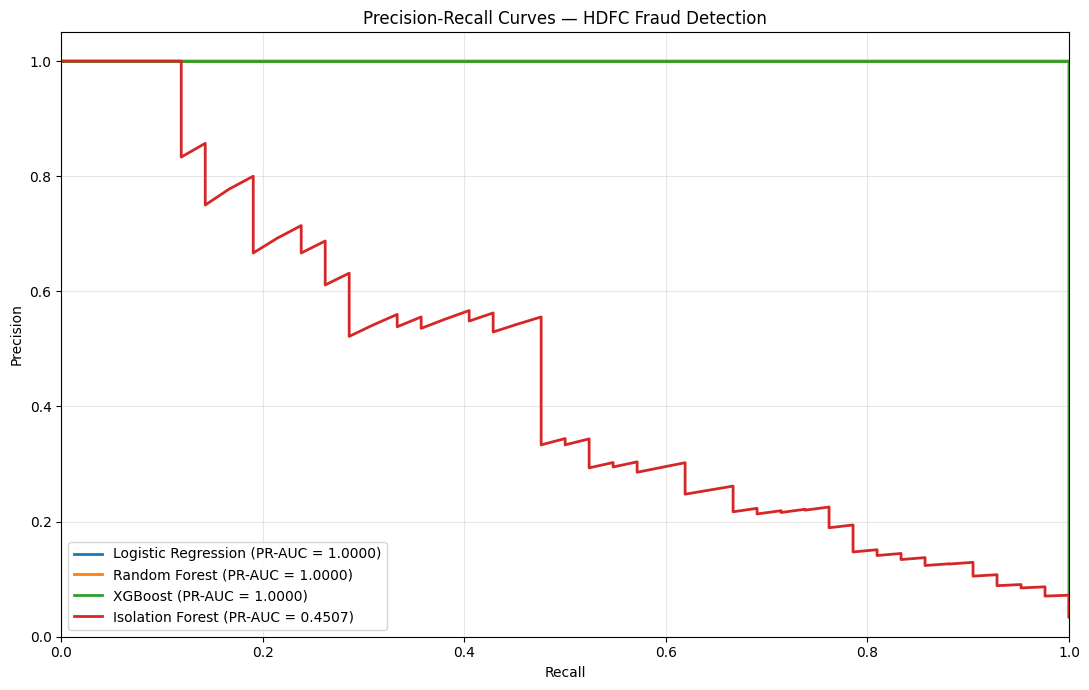

PR curve saved as hdfc_fraud_precision_recall.png


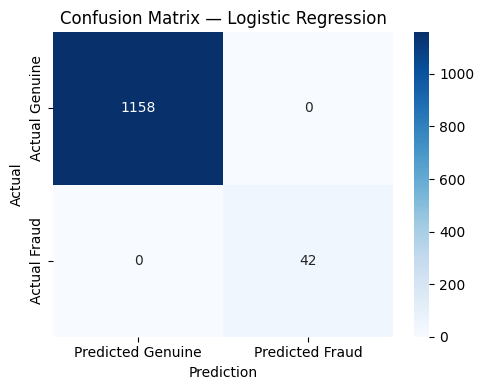

Model with highest PR-AUC in this test run: Logistic Regression


In [19]:
# ============================================================
# STEP 14: PRECISION-RECALL CURVES + CONFUSION MATRICES
# ============================================================

from sklearn.metrics import precision_recall_curve, auc

scores = {
    "Logistic Regression": lr_proba,
    "Random Forest": rf_proba,
    "XGBoost": xgb_proba,
    "Isolation Forest": iso_proba
}

plt.figure(figsize=(11, 7))

for name, score in scores.items():
    precision, recall, _ = precision_recall_curve(y_test, score)
    pr_auc_value = auc(recall, precision)
    plt.plot(recall, precision, linewidth=2,
             label=f"{name} (PR-AUC = {pr_auc_value:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — HDFC Fraud Detection")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("hdfc_fraud_precision_recall.png", dpi=300, bbox_inches="tight")
plt.show()

print("PR curve saved as hdfc_fraud_precision_recall.png")


# Confusion matrix for the supervised model with the highest PR-AUC
best_name = comparison.loc[comparison["PR-AUC"].idxmax(), "Model"]
pred_lookup = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "Isolation Forest": iso_pred
}

best_pred = pred_lookup[best_name]
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted Genuine", "Predicted Fraud"],
    yticklabels=["Actual Genuine", "Actual Fraud"]
)
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("hdfc_fraud_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Model with highest PR-AUC in this test run:", best_name)


---
## Step 15 — Final Business-Ready Fraud Risk Output

**What:** Create a transaction-level table with the original transaction information, actual label, model predictions and fraud-risk scores.

**Why:** A banking fraud team needs an actionable alert list rather than only model metrics.

The report is sorted by XGBoost fraud probability when available, because the score can be used to prioritise transactions for review. This is a ranking for operational review, not proof that a transaction is fraudulent.


In [20]:
# ============================================================
# STEP 15: FINAL BUSINESS-READY OUTPUT
# ============================================================

# Keep original test transactions
results = X_test.copy()

# Add ground truth
results["Actual_Fraud"] = y_test.values

# Add predictions and scores from all models
results["LR_Predicted_Fraud"] = lr_pred
results["LR_Fraud_Probability"] = lr_proba.round(4)

results["RF_Predicted_Fraud"] = rf_pred
results["RF_Fraud_Probability"] = rf_proba.round(4)

results["XGB_Predicted_Fraud"] = xgb_pred
results["XGB_Fraud_Probability"] = xgb_proba.round(4)

results["IsolationForest_Anomaly"] = iso_proba.round(4)
results["IsolationForest_Predicted_Fraud"] = iso_pred

# Business-facing alert label using XGBoost probability
results["Risk_Label"] = np.select(
    [
        results["XGB_Fraud_Probability"] >= 0.80,
        results["XGB_Fraud_Probability"] >= 0.50
    ],
    [
        "High Risk",
        "Review"
    ],
    default="Low Risk"
)

# Highest XGBoost risk first
results = results.sort_values(
    by="XGB_Fraud_Probability",
    ascending=False
)

display(results.head(20))

# Save outputs
comparison.to_csv("hdfc_fraud_model_comparison.csv", index=False)
results.to_csv("hdfc_fraud_risk_report.csv", index=False)

print("\nFiles created:")
print("1. hdfc_fraud_model_comparison.csv")
print("2. hdfc_fraud_risk_report.csv")
print("3. hdfc_fraud_precision_recall.png")
print("4. hdfc_fraud_confusion_matrix.png")


,transaction_date,transaction_time,merchant_category,transaction_type,device_type,card_present,home_city,transaction_city,distance_from_home_km,account_age_days,...,Actual_Fraud,LR_Predicted_Fraud,LR_Fraud_Probability,RF_Predicted_Fraud,RF_Fraud_Probability,XGB_Predicted_Fraud,XGB_Fraud_Probability,IsolationForest_Anomaly,IsolationForest_Predicted_Fraud,Risk_Label
3795,2026-02-05,01:08:00,Dining,POS,USSD,No,Jaipur,Hyderabad,646.3,55,...,1,1,1.0000,1,0.8933,1,0.9998,0.6041,1,High Risk
5676,2026-06-10,23:20:00,Pharmacy,UPI,Web Browser,No,Ahmedabad,Chennai,681.1,37,...,1,1,1.0000,1,0.8933,1,0.9998,0.4787,1,High Risk
5623,2026-07-11,03:28:00,Dining,ONLINE,Web Browser,No,Jaipur,Kolkata,709.6,26,...,1,1,1.0000,1,0.8967,1,0.9998,0.5325,1,High Risk
4762,2026-06-23,00:08:00,Fuel,ATM,Web Browser,No,Mumbai,Ahmedabad,1256.8,42,...,1,1,1.0000,1,0.8900,1,0.9998,0.5701,1,High Risk
864,2026-07-26,01:51:00,ATM Withdrawal,ONLINE,USSD,No,Delhi,Kolkata,654.5,23,...,1,1,1.0000,1,0.9200,1,0.9998,0.5548,1,High Risk
1041,2026-01-07,02:08:00,Fuel,POS,USSD,No,Mumbai,Bengaluru,287.8,5,...,1,1,0.9956,1,0.8733,1,0.9998,0.3616,1,High Risk
222,2026-05-18,01:45:00,E-commerce,UPI,USSD,No,Chennai,Mumbai,959.7,2,...,1,1,1.0000,1,0.8433,1,0.9998,0.6731,1,High Risk
4889,2026-08-03,23:34:00,E-commerce,ONLINE,USSD,No,Rajpura,Jaipur,1415.7,26,...,1,1,1.0000,1,0.9067,1,0.9998,0.7662,1,High Risk
1541,2026-04-10,02:59:00,Travel,POS,USSD,No,Mumbai,Hyderabad,590.7,51,...,1,1,1.0000,1,0.8400,1,0.9998,0.4611,1,High Risk
3266,2026-05-07,03:49:00,Utility Bill,POS,USSD,No,Mumbai,Ahmedabad,1593.5,45,...,1,1,1.0000,1,0.8633,1,0.9998,0.8382,1,High Risk



Files created:
1. hdfc_fraud_model_comparison.csv
2. hdfc_fraud_risk_report.csv
3. hdfc_fraud_precision_recall.png
4. hdfc_fraud_confusion_matrix.png


---
# ✅ Final Summary

You now have a complete **SmartKart-style end-to-end HDFC fraud detection pipeline**:

- Data collection
- Data inspection
- Duplicate and basic data cleaning
- Feature selection
- Target definition and encoding
- Stratified train-test split
- Reusable preprocessing pipeline
- Logistic Regression
- Random Forest
- XGBoost
- Isolation Forest
- Accuracy, Precision, Recall and F1
- ROC-AUC and PR-AUC
- Precision-Recall curves
- Confusion matrix
- Transaction-level fraud-risk report

### Important improvement over the old HDFC notebook

The old notebook contained manually entered ROC-AUC/PR-AUC values and manually created Precision-Recall points. Those values are **not recalculated from the uploaded HDFC dataset**.

This notebook calculates the metrics and curves from actual model predictions, making the results reproducible and suitable for a project submission.

### GitHub commit suggestion

`Day 3: HDFC fraud detection - complete ML pipeline with LR, RF, XGBoost and Isolation Forest`
